In [86]:
# Custom Spatial Message Passing Layer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree


class SpatialMessagePassing(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim=1):
        super(SpatialMessagePassing, self).__init__(aggr="add")

        self.in_channels = in_channels
        self.out_channels = out_channels

        # شبکه‌های عصبی برای ترکیب نیروی کولنی با ویژگی‌های نود
        # حالا نیروی کولنی خود پیام است، نه وزن
        self.message_net_x = nn.Sequential(
            nn.Linear(
                in_channels * 2 + edge_dim + 1, out_channels
            ),  # +1 for Coulomb force in x direction
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

        self.message_net_y = nn.Sequential(
            nn.Linear(
                in_channels * 2 + edge_dim + 1, out_channels
            ),  # +1 for Coulomb force in y direction
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

        self.message_net_z = nn.Sequential(
            nn.Linear(
                in_channels * 2 + edge_dim + 1, out_channels
            ),  # +1 for Coulomb force in z direction
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

        # شبکه نهایی برای ترکیب پیام‌ها از سه راستا
        self.combine_net = nn.Sequential(
            nn.Linear(out_channels * 3, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

        # شبکه برای به‌روزرسانی نهایی نود
        self.update_net = nn.Sequential(
            nn.Linear(in_channels + out_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x, edge_index, edge_attr, pos, atomic_numbers=None):
        """
        x: node features [num_nodes, in_channels]
        edge_index: [2, num_edges]
        edge_attr: edge features [num_edges, edge_dim]
        pos: node positions [num_nodes, 3]
        atomic_numbers: atomic numbers [num_nodes] - from data.z
        """
        # محاسبه بردار تفاضل مختصات برای هر یال
        row, col = edge_index
        diff_pos = pos[row] - pos[col]  # [num_edges, 3]

        # جداسازی مولفه‌های فضایی
        diff_x = diff_pos[:, 0].unsqueeze(1)  # [num_edges, 1]
        diff_y = diff_pos[:, 1].unsqueeze(1)  # [num_edges, 1]
        diff_z = diff_pos[:, 2].unsqueeze(1)  # [num_edges, 1]

        # محاسبه نیروی کولنی در هر راستا (حالا این خود پیام است)
        if atomic_numbers is not None:
            # عدد اتمی مبدا و مقصد برای هر یال
            atomic_i = atomic_numbers[row].float().unsqueeze(1)  # [num_edges, 1]
            atomic_j = atomic_numbers[col].float().unsqueeze(1)  # [num_edges, 1]

            # محاسبه نیروی کولنی: F = k * (Z_i * Z_j) / r²
            # در هر راستا: F_x = F * (Δx / |r|)
            epsilon = 1e-8


            # نیروی کولنی کل
            coulomb_force_magnitude = (
                atomic_i * atomic_j
            ) # [num_edges, 1]

            # نیروی کولنی در هر راستا (این خود پیام‌ها هستند)
            self.coulomb_force_x = coulomb_force_magnitude * (
                diff_x
            )  # [num_edges, 1]
            self.coulomb_force_y = coulomb_force_magnitude * (
                diff_y
            )  # [num_edges, 1]
            self.coulomb_force_z = coulomb_force_magnitude * (
                diff_z
            )  # [num_edges, 1]

        # propagate messages
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        """
        محاسبه پیام برای هر یال - حالا نیروی کولنی خود پیام است
        x_i: target node features [num_edges, in_channels]
        x_j: source node features [num_edges, in_channels]
        edge_attr: edge features [num_edges, edge_dim]
        """
        # ترکیب ویژگی‌های نود مبدا، مقصد و یال
        base_input = torch.cat([x_i, x_j, edge_attr], dim=-1)

        # محاسبه پیام در راستای x - نیروی کولنی به عنوان پیام اصلی
        input_x = torch.cat([base_input, self.coulomb_force_x], dim=-1)
        message_x = self.message_net_x(input_x)

        # محاسبه پیام در راستای y - نیروی کولنی به عنوان پیام اصلی
        input_y = torch.cat([base_input, self.coulomb_force_y], dim=-1)
        message_y = self.message_net_y(input_y)

        # محاسبه پیام در راستای z - نیروی کولنی به عنوان پیام اصلی
        input_z = torch.cat([base_input, self.coulomb_force_z], dim=-1)
        message_z = self.message_net_z(input_z)

        # ترکیب پیام‌ها از سه راستا
        combined_message = torch.cat([message_x, message_y, message_z], dim=-1)
        final_message = self.combine_net(combined_message)

        return final_message

    def update(self, aggr_out, x):
        """
        به‌روزرسانی ویژگی‌های نود با پیام‌های جمع‌آوری شده
        aggr_out: aggregated messages [num_nodes, out_channels]
        x: original node features [num_nodes, in_channels]
        """
        combined = torch.cat([x, aggr_out], dim=-1)
        return self.update_net(combined)

In [87]:
# Dataset Creation Imports
import glob
import pandas as pd
import yaml
import itertools
from pymatgen.core import Structure, Element
import torch
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn.conv import TransformerConv
from torch_geometric.nn.glob import global_mean_pool
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import DimeNet
import math
np.math = math
import torch_sparse
from torch_sparse import SparseTensor
import torch_scatter
import torch_cluster
import torch_spline_conv
from torch_geometric.nn import GlobalAttention
from torch_geometric.nn import MessagePassing

In [107]:
class GNNModel(nn.Module):
    def __init__(self, n_atom_features, n_output_freqs, edge_dim=1):
        super().__init__()
        hidden_channels = 16
        spatial_hidden_channels = 32

        # جایگزینی DimeNet با لایه فضایی سفارشی
        self.spatial_conv = SpatialMessagePassing(
            in_channels=n_atom_features,
            out_channels=spatial_hidden_channels,
            edge_dim=edge_dim,
        )
        self.bn_spatial = nn.BatchNorm1d(spatial_hidden_channels)

        self.embedding = TransformerConv(
            n_atom_features, hidden_channels, edge_dim=edge_dim
        )
        self.convs = nn.ModuleList(
            [
                TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
                for _ in range(2)
            ]
        )

        self.bn_embedding = nn.BatchNorm1d(hidden_channels)
        self.bns = nn.ModuleList(
            [nn.BatchNorm1d(hidden_channels) for _ in range(len(self.convs))]
        )

        self.global_mlp = nn.Sequential(nn.Linear(1, 1), nn.ReLU(), nn.BatchNorm1d(1))
        self.u_scale_factor = nn.Parameter(torch.ones(1))

        temp = 2048
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels + spatial_hidden_channels + 1, temp // 4),
            nn.BatchNorm1d(temp // 4),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(temp // 4, temp // 2),
            nn.BatchNorm1d(temp // 2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(temp // 2, temp // 1),
            nn.BatchNorm1d(temp // 1),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(temp // 1, n_output_freqs),
        )
        self.scale_factor = nn.Parameter(torch.ones(1))
        gate_nn = nn.Sequential(nn.Linear(hidden_channels, 1), nn.Sigmoid())
        self.pool = GlobalAttention(gate_nn=gate_nn)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, pos = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
            data.pos,
        )
        
        # استخراج اعداد اتمی اگر در دسترس باشد
        atomic_numbers = getattr(data, 'z', None)

        # استفاده از لایه فضایی جدید به جای DimeNet با اعداد اتمی
        spatial_embedding = self.spatial_conv(x, edge_index, edge_attr, pos, atomic_numbers)
        spatial_embedding = self.bn_spatial(spatial_embedding)
        spatial_embedding = spatial_embedding.tanh()

        # Global pooling برای spatial embedding
        spatial_pooled = global_mean_pool(spatial_embedding, batch)

        x = self.embedding(x, edge_index, edge_attr)
        x = self.bn_embedding(x)
        x = x.tanh()

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = x.tanh()

        pooled_x = self.pool(x, batch)

        combined_vector = torch.cat(
            [spatial_pooled, self.scale_factor * pooled_x, self.u_scale_factor * u],
            dim=1,
        )

        output = self.mlp(combined_vector)

        return output

In [108]:
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 1000

dataset_path = 'dataset.pt'
try:
    dataset = torch.load(dataset_path, weights_only=False)
    print(f"Successfully loaded dataset with {len(dataset)} graphs from {dataset_path}")
except FileNotFoundError:
    print(f"Error: Dataset file not found at '{dataset_path}'.")
    exit()

# استفاده از تابع consistent splitting به جای shuffle دستی
train_dataset, val_dataset, train_indices, val_indices = create_consistent_train_val_split(
    dataset, train_ratio=0.8, random_seed=42
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Successfully loaded dataset with 358 graphs from dataset.pt
🔒 Consistent Dataset Split Created:
   📊 Total samples: 358
   🎯 Training samples: 286 (indices: 0-354)
   ✅ Validation samples: 72 (indices: 1-357)
   🔑 Random seed: 42
   📝 This split will be EXACTLY the same every time with seed=42
Training on 286 samples, validating on 72 samples.


c:\ProgramData\anaconda3\envs\cuda-pytorch\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [109]:
# 🔒 Consistent Dataset Splitting Function
def create_consistent_train_val_split(dataset, train_ratio=0.8, random_seed=42):
    """
    ایجاد split ثابت و قابل تکرار برای train/validation
    این تابع همیشه با همان seed، همان تقسیم‌بندی را تولید می‌کند
    
    Args:
        dataset: لیست داده‌ها
        train_ratio: نسبت داده‌های آموزشی (پیش‌فرض: 0.8)
        random_seed: seed تصادفی برای تکرارپذیری (پیش‌فرض: 42)
    
    Returns:
        tuple: (train_dataset, val_dataset, train_indices, val_indices)
    """
    import torch
    import numpy as np
    
    # تنظیم seed برای تکرارپذیری
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    
    # ایجاد لیست ایندکس‌ها
    total_samples = len(dataset)
    indices = list(range(total_samples))
    
    # shuffle کردن ایندکس‌ها (نه خود dataset)
    np.random.shuffle(indices)
    
    # محاسبه تعداد نمونه‌های آموزشی
    train_size = int(total_samples * train_ratio)
    
    # تقسیم ایندکس‌ها
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # ایجاد dataset‌های جداگانه با استفاده از ایندکس‌ها
    train_dataset = [dataset[i] for i in train_indices]
    val_dataset = [dataset[i] for i in val_indices]
    
    print(f"🔒 Consistent Dataset Split Created:")
    print(f"   📊 Total samples: {total_samples}")
    print(f"   🎯 Training samples: {len(train_dataset)} (indices: {min(train_indices)}-{max(train_indices)})")
    print(f"   ✅ Validation samples: {len(val_dataset)} (indices: {min(val_indices)}-{max(val_indices)})")
    print(f"   🔑 Random seed: {random_seed}")
    print(f"   📝 This split will be EXACTLY the same every time with seed={random_seed}")
    
    return train_dataset, val_dataset, train_indices, val_indices

print("✅ Consistent dataset splitting function defined!")
print("🔒 This ensures the same train/val split every time with the same seed")
print("🎯 Now sample #71 in validation will always be the same sample!")

✅ Consistent dataset splitting function defined!
🔒 This ensures the same train/val split every time with the same seed
🎯 Now sample #71 in validation will always be the same sample!


In [110]:
# 🎯 Custom Band-Averaged RMSE Loss Function
class BandAveragedRMSELoss(nn.Module):
    def __init__(self, n_qpoints=357, n_bands=24):
        super(BandAveragedRMSELoss, self).__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        
    def forward(self, pred, target):
        """
        محاسبه Band-Averaged RMSE Loss
        pred: [batch_size, n_qpoints * n_bands] 
        target: [batch_size, n_qpoints * n_bands]
        """
        batch_size = pred.shape[0]
        
        # Reshape to [batch_size, n_qpoints, n_bands]
        pred_bands = pred.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target.view(batch_size, self.n_qpoints, self.n_bands)
        
        # محاسبه MSE برای هر band بر روی همه samples و qpoints
        # [batch_size, n_bands]
        mse_per_band = torch.mean((pred_bands - target_bands) ** 2, dim=1)
        
        # محاسبه RMSE برای هر band
        # [batch_size, n_bands]  
        rmse_per_band = torch.sqrt(mse_per_band)
        
        # میانگین RMSE بر روی همه bands و samples
        band_averaged_rmse = torch.mean(rmse_per_band)
        
        return band_averaged_rmse

print("✅ Custom Band-Averaged RMSE Loss Function defined!")
print("📊 This loss function:")
print("   • Calculates RMSE for each of the 24 phonon bands separately")
print("   • Takes the average of all band RMSEs")  
print("   • Treats each band equally in the loss calculation")
print("   • Should improve band-wise prediction accuracy")

✅ Custom Band-Averaged RMSE Loss Function defined!
📊 This loss function:
   • Calculates RMSE for each of the 24 phonon bands separately
   • Takes the average of all band RMSEs
   • Treats each band equally in the loss calculation
   • Should improve band-wise prediction accuracy


In [111]:
# 🎯 Custom Power-4 Loss Function (More Sensitive to Large Errors)
class Power4Loss(nn.Module):
    def __init__(self):
        super(Power4Loss, self).__init__()
        
    def forward(self, pred, target):
        """
        محاسبه Power-4 Loss: Fourth root of mean fourth power
        Similar to RMSE but with power 4 instead of power 2
        More sensitive to large errors than RMSE
        """
        # محاسبه خطا
        errors = pred - target
        
        # توان 4 به جای توان 2
        fourth_power_errors = torch.pow(torch.abs(errors), 4)
        
        # میانگین
        mean_fourth_power = torch.mean(fourth_power_errors)
        
        # ریشه چهارم به جای جذر
        power4_loss = torch.pow(mean_fourth_power, 0.25)  # fourth root
        
        return power4_loss

# 🎯 Custom Power-3 Loss Function (Moderate Sensitivity to Large Errors)
class Power3Loss(nn.Module):
    def __init__(self):
        super(Power3Loss, self).__init__()
        
    def forward(self, pred, target):
        """
        محاسبه Power-3 Loss: Cube root of mean cubic power
        Moderate sensitivity between RMSE and Power-4
        Uses power 3 and cube root
        """
        # محاسبه خطا
        errors = pred - target
        
        # قدر مطلق و توان 3
        cubic_power_errors = torch.pow(torch.abs(errors), 3)
        
        # میانگین
        mean_cubic_power = torch.mean(cubic_power_errors)
        
        # ریشه سوم
        power3_loss = torch.pow(mean_cubic_power, 1.0/3.0)  # cube root
        
        return power3_loss

print("✅ Custom Power-4 Loss Function defined!")
print("📊 This loss function:")
print("   • Uses power 4 instead of power 2 (like RMSE)")
print("   • Takes fourth root instead of square root")  
print("   • MUCH more sensitive to large errors than RMSE")
print("   • Should penalize outliers more aggressively")
print("   • Formula: (mean(|pred - target|^4))^(1/4)")

print("\n✅ Custom Power-3 Loss Function defined!")
print("📊 This loss function:")
print("   • Uses power 3 instead of power 2 (like RMSE)")
print("   • Takes cube root instead of square root")  
print("   • MORE sensitive to large errors than RMSE")
print("   • Moderate sensitivity between RMSE and Power-4")
print("   • Formula: (mean(|pred - target|^3))^(1/3)")

✅ Custom Power-4 Loss Function defined!
📊 This loss function:
   • Uses power 4 instead of power 2 (like RMSE)
   • Takes fourth root instead of square root
   • MUCH more sensitive to large errors than RMSE
   • Should penalize outliers more aggressively
   • Formula: (mean(|pred - target|^4))^(1/4)

✅ Custom Power-3 Loss Function defined!
📊 This loss function:
   • Uses power 3 instead of power 2 (like RMSE)
   • Takes cube root instead of square root
   • MORE sensitive to large errors than RMSE
   • Moderate sensitivity between RMSE and Power-4
   • Formula: (mean(|pred - target|^3))^(1/3)


In [112]:
# 🎯 Loss Function Selection - Choose MAE, RMSE, Band-Averaged RMSE, Power-3, or Power-4
print("🔧 Loss Function Configuration")
print("=" * 40)

# انتخاب تابع هزینه - فقط یکی از این‌ها را True کنید
USE_MAE = False           # Mean Absolute Error
USE_RMSE = True         # Root Mean Square Error  
USE_BAND_AVG_RMSE = False # Band-Averaged Root Mean Square Error
USE_POWER3 = False       # Power-3 Loss (Moderate sensitivity to large errors)
USE_POWER4 = False        # Power-4 Loss (Maximum sensitivity to large errors)

# Custom RMSE Loss Class
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()
        
    def forward(self, pred, target):
        return torch.sqrt(nn.MSELoss()(pred, target))

# انتخاب تابع هزینه بر اساس تنظیمات
if USE_MAE and not any([USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4]):
    criterion = nn.L1Loss()  # MAE Loss
    loss_name = "MAE (Mean Absolute Error)"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures average absolute difference in {loss_unit}")
    print(f"🎯 More robust to outliers compared to MSE")
    
elif USE_RMSE and not any([USE_MAE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4]):
    criterion = RMSELoss()  # RMSE Loss
    loss_name = "RMSE (Root Mean Square Error)"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures RMS difference in {loss_unit}")
    print(f"🎯 Penalizes large errors more than MAE")
    
elif USE_BAND_AVG_RMSE and not any([USE_MAE, USE_RMSE, USE_POWER3, USE_POWER4]):
    criterion = BandAveragedRMSELoss(n_qpoints=357, n_bands=24)  # Band-Averaged RMSE Loss
    loss_name = "Band-Averaged RMSE"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures average RMSE across 24 phonon bands")
    print(f"🎯 Treats each band equally - improves per-band accuracy")
    print(f"🔬 Based on evaluation metrics from cell 17")
    
elif USE_POWER3 and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER4]):
    criterion = Power3Loss()  # Power-3 Loss
    loss_name = "Power-3 Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss = (mean(|error|^3))^(1/3)")
    print(f"🎯 MORE sensitive to large errors than RMSE!")
    print(f"🟠 Moderate sensitivity between RMSE and Power-4")
    print(f"⚡ Good balance of outlier penalization")
    
elif USE_POWER4 and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3]):
    criterion = Power4Loss()  # Power-4 Loss
    loss_name = "Power-4 Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss = (mean(|error|^4))^(1/4)")
    print(f"🎯 MUCH more sensitive to large errors than RMSE!")
    print(f"🔥 Should aggressively penalize outliers and bad predictions")
    print(f"⚡ Higher sensitivity → Better fine-tuning of predictions")
    
elif sum([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4]) > 1:
    # اگر بیش از یکی انتخاب شده باشند، از Power-4 استفاده می‌کنیم
    criterion = Power4Loss()
    loss_name = "Power-4 Loss"
    loss_unit = "THz"
    print(f"⚠️  Multiple loss functions selected - defaulting to Power-4 Loss")
    print(f"✅ Using: {loss_name}")
    
else:
    # اگر هیچ کدام انتخاب نشده باشند، از MSE استفاده می‌کنیم
    criterion = nn.MSELoss()
    loss_name = "MSE (Mean Square Error)"
    loss_unit = "THz²"
    print(f"⚠️  No loss function selected - defaulting to MSE")
    print(f"✅ Using: {loss_name}")

print(f"📋 Loss Function: {loss_name}")
print(f"📏 Units: {loss_unit}")
print("=" * 40)

🔧 Loss Function Configuration
✅ Selected: RMSE (Root Mean Square Error)
📊 Loss measures RMS difference in THz
🎯 Penalizes large errors more than MAE
📋 Loss Function: RMSE (Root Mean Square Error)
📏 Units: THz


In [113]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")


Using device: cuda


In [114]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

n_atom_features = train_dataset[0].x.shape[1]
output_shape = train_dataset[0].y.shape[1]
edge_feature_dim = train_dataset[0].edge_attr.shape[1] 

model = GNNModel(
    n_atom_features=n_atom_features, 
    n_output_freqs=output_shape, 
    edge_dim=edge_feature_dim
).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50, min_lr=1e-6)

# استفاده از تابع هزینه انتخاب شده در سل قبلی
print(f"📊 Loss Function: {loss_name}")
print(f"📏 Loss Units: {loss_unit}")

print("\n--- Model Architecture ---")
print(model)
print("\n--- Starting Training ---")


Using device: cuda
📊 Loss Function: RMSE (Root Mean Square Error)
📏 Loss Units: THz

--- Model Architecture ---
GNNModel(
  (spatial_conv): SpatialMessagePassing(76, 32)
  (bn_spatial): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (embedding): TransformerConv(76, 16, heads=1)
  (convs): ModuleList(
    (0-1): 2 x TransformerConv(16, 16, heads=1)
  )
  (bn_embedding): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (global_mlp): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=49, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): D

c:\ProgramData\anaconda3\envs\cuda-pytorch\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


In [115]:
import sys

# Simple lists to store basic training data for later plotting
train_losses = []
val_losses = []

# Simple Early Stopping variables
best_val_loss = float('inf')
best_model_state = None
patience = 300  # Wait 50 epochs without improvement
wait_count = 0

print("Starting training with Early Stopping...")

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    total_train_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * data.num_graphs
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    if len(val_loader) > 0:
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                output = model(data)
                loss = criterion(output, data.y)
                total_val_loss += loss.item() * data.num_graphs
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
    else:
        avg_val_loss = 0.0
        val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    
    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()  # Save best model
        wait_count = 0
        best_epoch = epoch
    else:
        wait_count += 1
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"   Best Val Loss: {best_val_loss:.4f} at epoch {best_epoch}, Wait: {wait_count}/{patience}")
        sys.stdout.flush()
    
    # Stop if no improvement for 'patience' epochs
    if wait_count >= patience:
        print(f"\nEarly stopping at epoch {epoch}!")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

# Load best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")

print("\nTraining finished with Early Stopping.")

# Save training data for later use
training_data = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'epochs': list(range(1, len(train_losses) + 1)),
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss
}

print(f"Training data saved for {len(train_losses)} epochs (stopped early).")

Starting training with Early Stopping...
Epoch: 010, Train Loss: 1.4557, Val Loss: 1.2843
   Best Val Loss: 1.2371 at epoch 9, Wait: 1/300
Epoch: 020, Train Loss: 1.3398, Val Loss: 1.2969
   Best Val Loss: 1.1945 at epoch 11, Wait: 9/300
Epoch: 030, Train Loss: 1.2223, Val Loss: 1.2031
   Best Val Loss: 1.0925 at epoch 28, Wait: 2/300
Epoch: 040, Train Loss: 1.1825, Val Loss: 0.9959
   Best Val Loss: 0.9959 at epoch 40, Wait: 0/300
Epoch: 050, Train Loss: 1.0554, Val Loss: 1.1224
   Best Val Loss: 0.9959 at epoch 40, Wait: 10/300
Epoch: 060, Train Loss: 1.0413, Val Loss: 1.0715
   Best Val Loss: 0.9465 at epoch 58, Wait: 2/300
Epoch: 070, Train Loss: 1.0505, Val Loss: 1.0145
   Best Val Loss: 0.9465 at epoch 58, Wait: 12/300
Epoch: 080, Train Loss: 0.9637, Val Loss: 0.9776
   Best Val Loss: 0.8798 at epoch 72, Wait: 8/300
Epoch: 090, Train Loss: 1.0301, Val Loss: 0.8654
   Best Val Loss: 0.8364 at epoch 88, Wait: 2/300
Epoch: 100, Train Loss: 0.9723, Val Loss: 0.9005
   Best Val Loss: 

In [116]:
# Save Best Model and Training Data
model_save_path = 'trained_gnn_model.pth'
training_data_path = 'training_data.pt'

# Save best model state (already loaded in model)
torch.save(model.state_dict(), model_save_path)
print(f"✅ Best model saved to: {model_save_path}")
print(f"   Best validation loss: {best_val_loss:.4f}")
print(f"   Best model from epoch: {best_epoch}")

# Save training data for plotting
torch.save(training_data, training_data_path)
print(f"✅ Training data saved to: {training_data_path}")

print(f"\nSaved data contains:")
print(f"  - {len(training_data['train_losses'])} training loss values")
print(f"  - {len(training_data['val_losses'])} validation loss values")
print(f"  - Best epoch: {training_data['best_epoch']}")
print(f"  - Early stopping prevented overfitting!")
print(f"  - Ready for plotting training curves")

✅ Best model saved to: trained_gnn_model.pth
   Best validation loss: 0.6670
   Best model from epoch: 786
✅ Training data saved to: training_data.pt

Saved data contains:
  - 1000 training loss values
  - 1000 validation loss values
  - Best epoch: 786
  - Early stopping prevented overfitting!
  - Ready for plotting training curves


In [117]:
# Load Training Data and Model for Continuation
import torch
import torch.nn as nn
from torch_geometric.data import DataLoader
import numpy as np
import os

# Check if training data exists and load it
training_data_path = 'training_data.pt'
model_path = 'trained_gnn_model.pth'
dataset_path = 'dataset.pt'

print("🔄 Loading saved data and model...")

# Load training data
if os.path.exists(training_data_path):
    try:
        training_data = torch.load(training_data_path, weights_only=False)
        print(f"✅ Successfully loaded training data from: {training_data_path}")
        print(f"📊 Loaded data contains:")
        print(f"   • {len(training_data['train_losses'])} training loss values")
        print(f"   • {len(training_data['val_losses'])} validation loss values")
        print(f"   • Epochs range: {training_data['epochs'][0]} to {training_data['epochs'][-1]}")
        print(f"   • Final training loss: {training_data['train_losses'][-1]:.4f}")
        print(f"   • Final validation loss: {training_data['val_losses'][-1]:.4f}")
        
        # Show early stopping info if available
        if 'best_epoch' in training_data:
            print(f"   🎯 EARLY STOPPING INFO:")
            print(f"   • Best model from epoch: {training_data['best_epoch']}")
            print(f"   • Best validation loss: {training_data['best_val_loss']:.4f}")
            print(f"   • Training stopped early to prevent overfitting!")
        else:
            print(f"   • No early stopping info (old training data)")
            
    except Exception as e:
        print(f"❌ Error loading training data: {e}")
        training_data = None
else:
    print(f"❌ Training data file not found: {training_data_path}")
    training_data = None

# Load dataset and create data loaders
if os.path.exists(dataset_path):
    try:
        dataset = torch.load(dataset_path, weights_only=False)
        print(f"✅ Successfully loaded dataset with {len(dataset)} graphs")
        
        # استفاده از همان تابع consistent splitting
        train_dataset, val_dataset, train_indices, val_indices = create_consistent_train_val_split(
            dataset, train_ratio=0.8, random_seed=42
        )
        
        # Create data loaders
        BATCH_SIZE = 32
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        print(f"📊 Dataset split: {len(train_dataset)} train, {len(val_dataset)} validation")
        
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        dataset = None
        val_dataset = None
        train_dataset = None
else:
    print(f"❌ Dataset file not found: {dataset_path}")
    dataset = None
    val_dataset = None
    train_dataset = None

# Load trained model (using previously defined GNNModel class)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

if os.path.exists(model_path) and dataset is not None and 'GNNModel' in globals():
    try:
        # Get model dimensions from dataset
        n_atom_features = train_dataset[0].x.shape[1]
        output_shape = train_dataset[0].y.shape[1]
        edge_feature_dim = train_dataset[0].edge_attr.shape[1]
        
        # Create model instance and load weights
        model = GNNModel(
            n_atom_features=n_atom_features,
            n_output_freqs=output_shape,
            edge_dim=edge_feature_dim
        ).to(device)
        
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        print(f"✅ Successfully loaded trained model from: {model_path}")
        print(f"🎯 Model ready for evaluation and predictions")
        print(f"📐 Model specs: {n_atom_features} atom features → {output_shape} frequencies")
        
        # Confirm best model is loaded
        if training_data and 'best_epoch' in training_data:
            print(f"✅ CONFIRMED: Best model loaded (from epoch {training_data['best_epoch']})")
            print(f"   Best validation loss: {training_data['best_val_loss']:.4f}")
        else:
            print(f"⚠️  Model loaded, but no early stopping info available")
        
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        model = None
else:
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
    if dataset is None:
        print(f"❌ Cannot load model without dataset")
    if 'GNNModel' not in globals():
        print(f"❌ GNNModel class not found - please run model definition cell first")
    model = None

# Create dummy data if training data not available
if training_data is None:
    print("🔧 Creating dummy training data for demonstration...")
    training_data = {
        'train_losses': [1.0, 0.8, 0.6, 0.4, 0.2],
        'val_losses': [1.1, 0.9, 0.7, 0.5, 0.3],
        'epochs': [1, 2, 3, 4, 5]
    }
    print("⚠️  Using dummy data - run actual training for real results")

# Summary
print(f"\n{'='*50}")
print("📋 LOADING SUMMARY:")
print(f"{'='*50}")
print(f"✅ Training Data: {'Loaded' if training_data else 'Not Available'}")
print(f"✅ Dataset: {'Loaded' if dataset else 'Not Available'}")
print(f"✅ Model: {'Loaded & Ready' if model else 'Not Available'}")
print(f"✅ Data Loaders: {'Ready' if val_dataset else 'Not Available'}")
print(f"✅ GNNModel Class: {'Available' if 'GNNModel' in globals() else 'Run cell 15 first'}")

# Final confirmation about best model
if model and training_data and 'best_epoch' in training_data:
    print(f"🎯 BEST MODEL STATUS: Loaded and ready!")
    print(f"   From epoch {training_data['best_epoch']} with validation loss {training_data['best_val_loss']:.4f}")
else:
    print(f"⚠️  Best model status unclear - check training data")

print(f"\n🎯 Status: {'All systems ready for evaluation!' if model and val_dataset else 'Please run model definition cell (15) first'}")
print(f"{'='*50}")

🔄 Loading saved data and model...
✅ Successfully loaded training data from: training_data.pt
📊 Loaded data contains:
   • 1000 training loss values
   • 1000 validation loss values
   • Epochs range: 1 to 1000
   • Final training loss: 0.5816
   • Final validation loss: 0.6900
   🎯 EARLY STOPPING INFO:
   • Best model from epoch: 786
   • Best validation loss: 0.6670
   • Training stopped early to prevent overfitting!
✅ Successfully loaded dataset with 358 graphs
🔒 Consistent Dataset Split Created:
   📊 Total samples: 358
   🎯 Training samples: 286 (indices: 0-354)
   ✅ Validation samples: 72 (indices: 1-357)
   🔑 Random seed: 42
   📝 This split will be EXACTLY the same every time with seed=42
📊 Dataset split: 286 train, 72 validation
🖥️  Using device: cuda
✅ Successfully loaded trained model from: trained_gnn_model.pth
🎯 Model ready for evaluation and predictions
📐 Model specs: 76 atom features → 8568 frequencies
✅ CONFIRMED: Best model loaded (from epoch 786)
   Best validation loss:

C:\Users\Victor\AppData\Local\Temp\ipykernel_38004\3663315129.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=

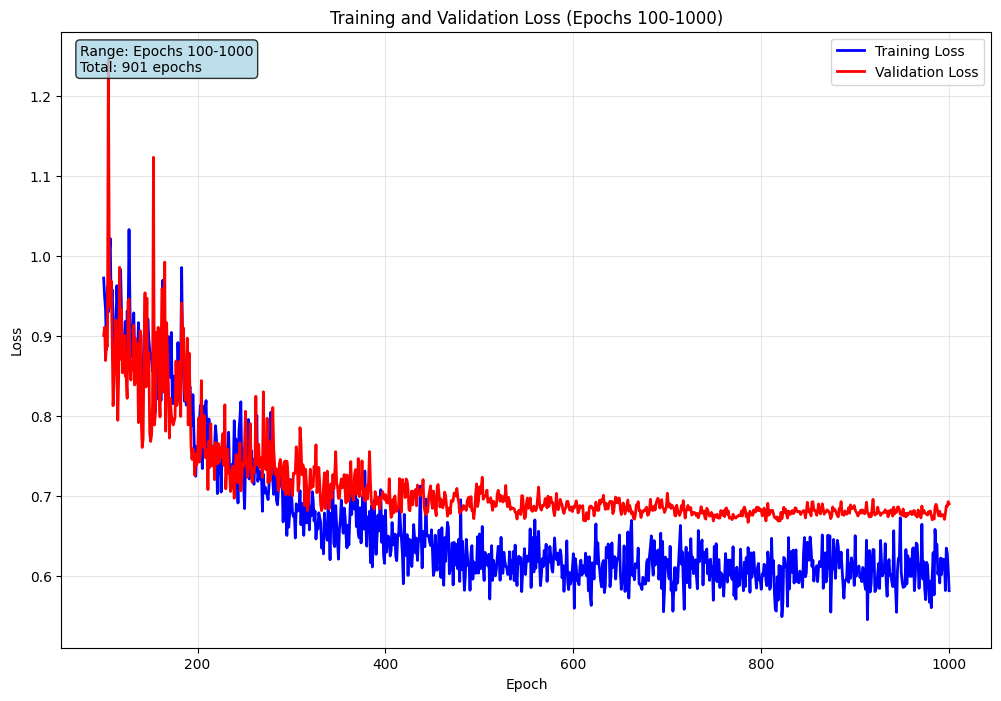

📊 Plot Range: Epochs 100 to 1000
📈 Training Loss - Start: 0.9723, End: 0.5816
📉 Validation Loss - Start: 0.9005, End: 0.6900
🎯 Loss Reduction - Training: 0.3907
🎯 Loss Reduction - Validation: 0.2104

💡 To change range: Modify start_epoch and end_epoch variables
   Example: start_epoch = 100, end_epoch = 500 (for epochs 100-500)
   Example: start_epoch = 1, end_epoch = 100 (for first 100 epochs)
   Example: start_epoch = 900, end_epoch = 1000 (for last 100 epochs)


In [118]:
# Simple Training Curves Plot with Range Selection
import matplotlib.pyplot as plt

# You can modify these values to plot specific ranges
start_epoch = 100          # Starting epoch for plot (1 for full range)
end_epoch = 1000    # Ending epoch for plot (use len(training_data['epochs']) for full range)

# Validate range
start_epoch = max(1, min(start_epoch, len(training_data['epochs'])))
end_epoch = min(end_epoch, len(training_data['epochs']))

if start_epoch > end_epoch:
    start_epoch, end_epoch = 1, len(training_data['epochs'])

# Extract data for the specified range
plot_epochs = training_data['epochs'][start_epoch-1:end_epoch]
plot_train_losses = training_data['train_losses'][start_epoch-1:end_epoch]
plot_val_losses = training_data['val_losses'][start_epoch-1:end_epoch]

plt.figure(figsize=(12, 8))
plt.plot(plot_epochs, plot_train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(plot_epochs, plot_val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True, alpha=0.3)

# Add range info text box
range_text = f'Range: Epochs {start_epoch}-{end_epoch}\nTotal: {end_epoch-start_epoch+1} epochs'
plt.text(0.02, 0.98, range_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.show()

print(f"📊 Plot Range: Epochs {start_epoch} to {end_epoch}")
print(f"📈 Training Loss - Start: {plot_train_losses[0]:.4f}, End: {plot_train_losses[-1]:.4f}")
print(f"📉 Validation Loss - Start: {plot_val_losses[0]:.4f}, End: {plot_val_losses[-1]:.4f}")
print(f"🎯 Loss Reduction - Training: {plot_train_losses[0] - plot_train_losses[-1]:.4f}")
print(f"🎯 Loss Reduction - Validation: {plot_val_losses[0] - plot_val_losses[-1]:.4f}")

print(f"\n💡 To change range: Modify start_epoch and end_epoch variables")
print(f"   Example: start_epoch = 100, end_epoch = 500 (for epochs 100-500)")
print(f"   Example: start_epoch = 1, end_epoch = 100 (for first 100 epochs)")
print(f"   Example: start_epoch = 900, end_epoch = 1000 (for last 100 epochs)")

In [119]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score

In [120]:
model.eval()
sample_index = 65
test_sample = val_dataset[sample_index].to(device)
print(f"Selected test sample #{sample_index} for prediction.")

with torch.no_grad():
    test_sample.batch = torch.zeros(test_sample.x.size(0), dtype=torch.long, device=device)
    predicted_y_tensor = model(test_sample)

Selected test sample #65 for prediction.


In [121]:
N_BANDS = 24
N_QPOINTS = 357

true_y = test_sample.y.cpu().numpy().flatten()
predicted_y = predicted_y_tensor.cpu().numpy().flatten()

true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
predicted_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

r2_value = r2_score(true_y, predicted_y)
print(f"\nCalculated R² Score for this sample: {r2_value:.4f}")

reference_yaml = 'band/band (1).yaml' 
with open(reference_yaml, 'r') as f:
    yaml_data = yaml.safe_load(f)
distances = [d['distance'] for d in yaml_data['phonon']]


Calculated R² Score for this sample: 0.9778


Plotting bands (1-based indices): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


C:\Users\Victor\AppData\Local\Temp\ipykernel_38004\2792548175.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('turbo', N_BANDS)


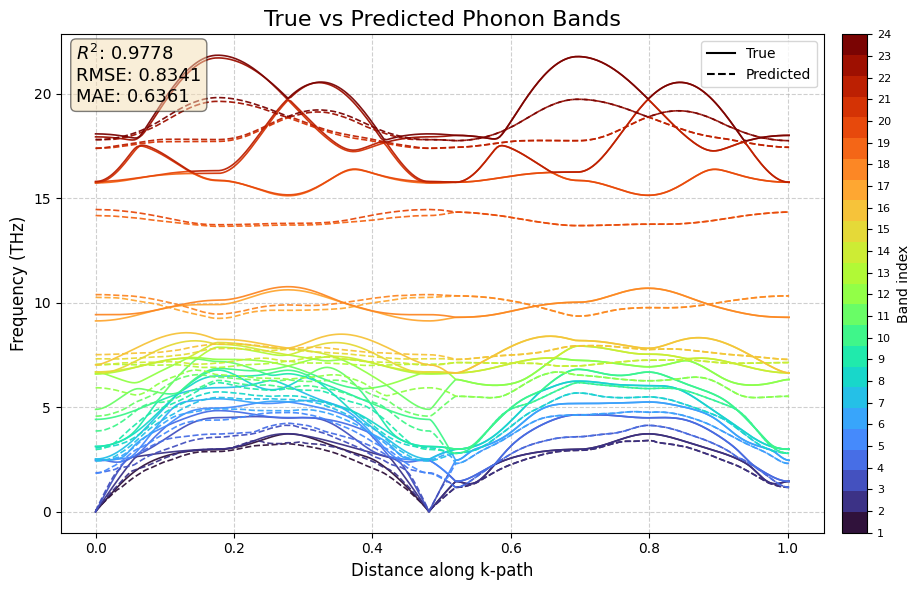


Per-band metrics (rounded to 4 decimals):
 Band       R2   RMSE    MAE
    1   0.9491 0.2396 0.2029
    2   0.9447 0.2481 0.1993
    3   0.8368 0.5739 0.4770
    4   0.7013 0.6255 0.5463
    5   0.8731 0.4280 0.3974
    6   0.8972 0.3599 0.3121
    7   0.9015 0.4305 0.3726
    8   0.8705 0.4828 0.4083
    9   0.9080 0.4445 0.3751
   10   0.8655 0.4716 0.4115
   11   0.2622 0.5952 0.5672
   12  -1.6590 0.6830 0.6707
   13  -0.1739 0.4794 0.4130
   14   0.0461 0.4493 0.3809
   15   0.4831 0.4271 0.3665
   16   0.4178 0.4399 0.3715
   17  -1.4801 0.7929 0.7340
   18  -1.5035 0.7562 0.7076
   19 -33.9268 1.8742 1.8438
   20 -31.3690 1.8039 1.7667
   21   0.0473 1.0788 0.9280
   22   0.0691 1.0748 0.9237
   23   0.3410 1.1887 0.9413
   24   0.3454 1.1747 0.9477

Averages across 24 bands (sum/count): R2=-2.4730, RMSE=0.7134, MAE=0.6361


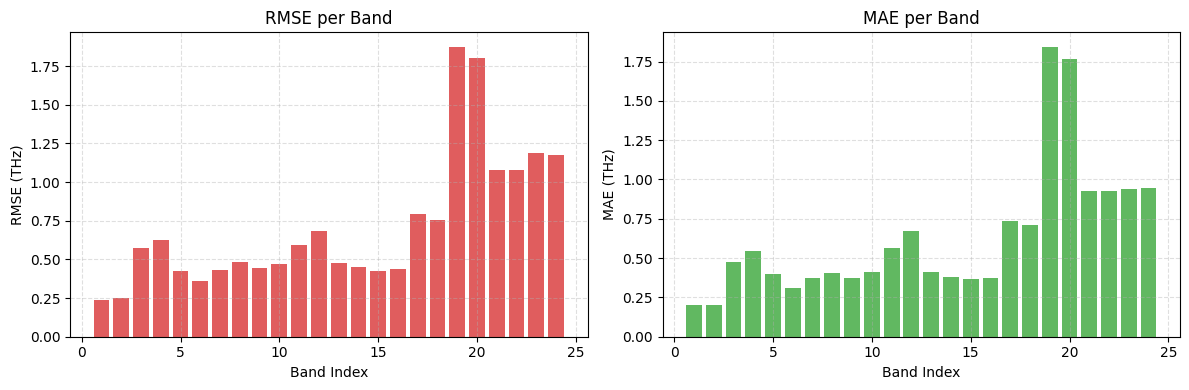

Overall -> R^2: 0.977788 | RMSE: 0.834130 | MAE: 0.636054


In [122]:
# Overlay true and predicted phonon bands in a single plot, with per-band colors and extra metrics (R^2, RMSE, MAE)
from matplotlib.lines import Line2D
import matplotlib as mpl
import pandas as pd

# ===== Band selection controls =====
# Options:
#   - band_selection = 'all'
#   - band_selection = '1-3,6,12-14'  # 1-based inclusive ranges and/or comma-separated indices
# band_selection = [17]    # list of 1-based indices
band_selection = 'all'  # change this to select which bands to plot

def parse_band_selection(sel, n):
    """Return a list of 0-based band indices to plot.
    Accepts 'all', a comma/range string like '1-3,6,10-12', or a list of ints (1-based)."""
    if sel is None:
        return list(range(n))
    if isinstance(sel, str):
        s = sel.strip().lower()
        if s == 'all' or s == '':
            return list(range(n))
        vals = []
        for part in s.replace(' ', '').split(','):
            if not part:
                continue
            if '-' in part:
                a, b = part.split('-')
                a, b = int(a), int(b)
                step = 1 if a <= b else -1
                vals.extend(list(range(a, b + step, step)))
            else:
                vals.append(int(part))
    else:
        # Assume iterable of ints
        vals = [int(v) for v in sel]

    # Convert to 0-based, validate, and de-duplicate while preserving order
    out, seen = [], set()
    for v in vals:
        idx = v - 1 if v >= 1 else v  # treat provided indices as 1-based
        if 0 <= idx < n and idx not in seen:
            out.append(idx)
            seen.add(idx)
    return out if out else list(range(n))

selected_idx = parse_band_selection(band_selection, N_BANDS)
selected_idx_1based = [i + 1 for i in selected_idx]
print(f"Plotting bands (1-based indices): {selected_idx_1based}")

# Compute overall error metrics using flattened arrays
errors = predicted_y - true_y
rmse_value = float(np.sqrt(np.mean(errors ** 2)))
mae_value = float(np.mean(np.abs(errors)))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Determine shared y-limits using both true and predicted bands
ymin = min(np.min(true_bands), np.min(predicted_bands)) - 1
ymax = max(np.max(true_bands), np.max(predicted_bands)) + 1

# Discrete colormap with N_BANDS distinct colors (consistent for true/predicted of the same band)
cmap = mpl.cm.get_cmap('turbo', N_BANDS)
colors_list = [cmap(i) for i in range(N_BANDS)]

# Plot only selected bands (same color per band index)
for i in selected_idx:
    c = colors_list[i]
    ax.plot(distances, true_bands[:, i], lw=1.2, color=c, alpha=0.95)
    ax.plot(distances, predicted_bands[:, i], lw=1.2, color=c, alpha=0.95, linestyle='--')

ax.set_title('True vs Predicted Phonon Bands', fontsize=16)
ax.set_xlabel('Distance along k-path', fontsize=12)
ax.set_ylabel('Frequency (THz)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(ymin, ymax)

# Legend for line style (True vs Predicted)
legend_elements = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='True'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Predicted')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# Colorbar to map colors to band index (1..N_BANDS)
norm = mpl.colors.Normalize(vmin=1, vmax=N_BANDS)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Band index')
# Use selected indices for ticks if a subset, otherwise all
if len(selected_idx) < N_BANDS:
    cbar.set_ticks(selected_idx_1based)
else:
    cbar.set_ticks(np.arange(1, N_BANDS + 1))
cbar.ax.tick_params(labelsize=8)

# Overall metrics annotation box
metrics_text = f"$R^2$: {r2_value:.4f}\nRMSE: {rmse_value:.4f}\nMAE: {mae_value:.4f}"
ax.text(0.02, 0.98, metrics_text,
        transform=ax.transAxes,
        fontsize=13,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Per-band metrics -----------------------------------------------------------
# Vectorized per-band RMSE/MAE
band_rmse = np.sqrt(np.mean((predicted_bands - true_bands) ** 2, axis=0))
band_mae = np.mean(np.abs(predicted_bands - true_bands), axis=0)

# Safe R^2 per band (handle near-constant ground-truth bands)
def _safe_r2(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

band_r2 = np.array([
    _safe_r2(true_bands[:, i], predicted_bands[:, i]) for i in range(N_BANDS)
])

# Assemble and print a neat table
metrics_df = pd.DataFrame({
    'Band': np.arange(1, N_BANDS + 1),
    'R2': band_r2,
    'RMSE': band_rmse,
    'MAE': band_mae,
})
print('\nPer-band metrics (rounded to 4 decimals):')
print(metrics_df.round({'R2': 4, 'RMSE': 4, 'MAE': 4}).to_string(index=False))

# Averages across all 24 bands (sum divided by count)
valid_r2_mask = ~np.isnan(band_r2)
avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
avg_mae_bands = float(np.sum(band_mae) / len(band_mae))
print(f"\nAverages across {np.sum(valid_r2_mask)} bands (sum/count): R2={avg_r2_bands:.4f}, RMSE={avg_rmse_bands:.4f}, MAE={avg_mae_bands:.4f}")

# Optional: compact bar charts for RMSE and MAE per band
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
bands_idx = np.arange(1, N_BANDS + 1)
axes2[0].bar(bands_idx, band_rmse, color='tab:red', alpha=0.75)
axes2[0].set_title('RMSE per Band')
axes2[0].set_xlabel('Band Index')
axes2[0].set_ylabel('RMSE (THz)')
axes2[0].grid(True, linestyle='--', alpha=0.4)

axes2[1].bar(bands_idx, band_mae, color='tab:green', alpha=0.75)
axes2[1].set_title('MAE per Band')
axes2[1].set_xlabel('Band Index')
axes2[1].set_ylabel('MAE (THz)')
axes2[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Also print overall metrics for logging
print(f"Overall -> R^2: {r2_value:.6f} | RMSE: {rmse_value:.6f} | MAE: {mae_value:.6f}")

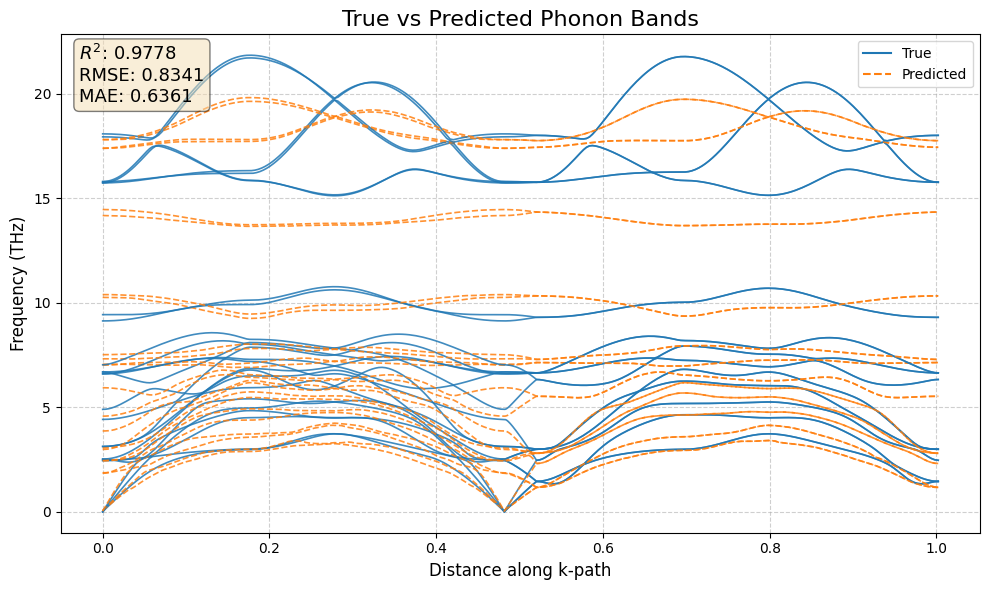

R^2: 0.977788 | RMSE: 0.834130 | MAE: 0.636054


In [123]:
# Overlay true and predicted phonon bands in a single plot, with extra metrics (R^2, RMSE, MAE)
from matplotlib.lines import Line2D

# Compute per-sample error metrics using flattened arrays
errors = predicted_y - true_y
rmse_value = float(np.sqrt(np.mean(errors ** 2)))
mae_value = float(np.mean(np.abs(errors)))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Determine shared y-limits using both true and predicted bands
ymin = min(np.min(true_bands), np.min(predicted_bands)) - 1
ymax = max(np.max(true_bands), np.max(predicted_bands)) + 1

# Plot both sets of bands on the same axes with different styles/colors
for i in range(N_BANDS):
    ax.plot(distances, true_bands[:, i], lw=1.2, color='tab:blue', alpha=0.85)
    ax.plot(distances, predicted_bands[:, i], lw=1.2, color='tab:orange', alpha=0.85, linestyle='--')

ax.set_title('True vs Predicted Phonon Bands', fontsize=16)
ax.set_xlabel('Distance along k-path', fontsize=12)
ax.set_ylabel('Frequency (THz)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(ymin, ymax)

# Add a compact legend using proxy artists for clarity
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=1.5, label='True'),
    Line2D([0], [0], color='tab:orange', lw=1.5, linestyle='--', label='Predicted')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# Metrics annotation box
metrics_text = f"$R^2$: {r2_value:.4f}\nRMSE: {rmse_value:.4f}\nMAE: {mae_value:.4f}"
ax.text(0.02, 0.98, metrics_text,
        transform=ax.transAxes,
        fontsize=13,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Also print metrics in the cell output for logging
print(f"R^2: {r2_value:.6f} | RMSE: {rmse_value:.6f} | MAE: {mae_value:.6f}")

In [124]:
model.eval()
all_r2_scores = []  # R² per sample using flattened arrays (kept for reference)

# New: per-sample averages of per-band metrics
sample_avg_r2 = []   # average of per-band R² per sample
sample_avg_rmse = [] # average of per-band RMSE per sample
sample_avg_mae = []  # average of per-band MAE per sample

print("\n--- Evaluating per-sample metrics (averaged over 24 bands) for all test samples ---")

# Safe R² helper for per-band computation
def _safe_r2(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

with torch.no_grad():
    for i, test_sample in enumerate(val_dataset):
        sample_on_device = test_sample.to(device)
        
        # Single-graph batch assignment
        sample_on_device.batch = torch.zeros(sample_on_device.x.size(0), dtype=torch.long, device=device)
        predicted_y_tensor = model(sample_on_device)
        
        true_y = sample_on_device.y.cpu().numpy().flatten()
        predicted_y = predicted_y_tensor.cpu().numpy().flatten()

        # Original overall R² for the flattened vectors
        r2 = r2_score(true_y, predicted_y)
        all_r2_scores.append(r2)

        # Reshape to (N_QPOINTS, N_BANDS) and compute per-band metrics like cell 38
        true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
        pred_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

        band_rmse = np.sqrt(np.mean((pred_bands - true_bands) ** 2, axis=0))
        band_mae = np.mean(np.abs(pred_bands - true_bands), axis=0)
        band_r2 = np.array([_safe_r2(true_bands[:, j], pred_bands[:, j]) for j in range(N_BANDS)])

        # Averages across 24 bands (sum/count); ignore NaNs in R²
        valid_r2_mask = ~np.isnan(band_r2)
        avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
        avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
        avg_mae_bands = float(np.sum(band_mae) / len(band_mae))

        sample_avg_r2.append(avg_r2_bands)
        sample_avg_rmse.append(avg_rmse_bands)
        sample_avg_mae.append(avg_mae_bands)

        print(f"  - Sample {i}: flat R²={r2:.4f} | band-avg R²={avg_r2_bands:.4f} | band-avg RMSE={avg_rmse_bands:.4f} | band-avg MAE={avg_mae_bands:.4f}")

# Summaries across all validation samples
average_r2 = np.mean(all_r2_scores)
avg_of_sample_avg_r2 = float(np.nanmean(sample_avg_r2)) if len(sample_avg_r2) > 0 else float('nan')
avg_of_sample_avg_rmse = float(np.mean(sample_avg_rmse)) if len(sample_avg_rmse) > 0 else float('nan')
avg_of_sample_avg_mae = float(np.mean(sample_avg_mae)) if len(sample_avg_mae) > 0 else float('nan')

print("-" * 60)
print(f"Average flat R² over {len(val_dataset)} test samples: {average_r2:.4f}")
print(f"Average of band-averaged metrics over {len(val_dataset)} samples:")
print(f"  • R² (band-avg then sample-avg): {avg_of_sample_avg_r2:.4f}")
print(f"  • RMSE (band-avg then sample-avg): {avg_of_sample_avg_rmse:.4f}")
print(f"  • MAE  (band-avg then sample-avg): {avg_of_sample_avg_mae:.4f}")
print("-" * 60)


--- Evaluating per-sample metrics (averaged over 24 bands) for all test samples ---
  - Sample 0: flat R²=0.9396 | band-avg R²=-55.2740 | band-avg RMSE=1.4451 | band-avg MAE=1.3798
  - Sample 1: flat R²=0.9923 | band-avg R²=-2.9837 | band-avg RMSE=0.5409 | band-avg MAE=0.5071
  - Sample 2: flat R²=0.9942 | band-avg R²=-0.6539 | band-avg RMSE=0.3659 | band-avg MAE=0.3350
  - Sample 3: flat R²=0.9955 | band-avg R²=-5.1793 | band-avg RMSE=0.3333 | band-avg MAE=0.3113
  - Sample 4: flat R²=0.9929 | band-avg R²=-3.3995 | band-avg RMSE=0.3723 | band-avg MAE=0.3375
  - Sample 5: flat R²=0.9889 | band-avg R²=-1.5648 | band-avg RMSE=0.5276 | band-avg MAE=0.4186
  - Sample 6: flat R²=0.9680 | band-avg R²=-3.5795 | band-avg RMSE=0.5540 | band-avg MAE=0.5146
  - Sample 7: flat R²=0.9236 | band-avg R²=-9.7490 | band-avg RMSE=1.0716 | band-avg MAE=1.0074
  - Sample 8: flat R²=0.9924 | band-avg R²=0.1337 | band-avg RMSE=0.3177 | band-avg MAE=0.2768
  - Sample 9: flat R²=0.9961 | band-avg R²=-0.8226 

In [127]:
# 🔄 Training Dataset Evaluation - Same Metrics as Validation
model.eval()
train_all_r2_scores = []  # R² per sample using flattened arrays (kept for reference)

# New: per-sample averages of per-band metrics for TRAINING data
train_sample_avg_r2 = []   # average of per-band R² per sample
train_sample_avg_rmse = [] # average of per-band RMSE per sample
train_sample_avg_mae = []  # average of per-band MAE per sample

print("\n🎯 --- Evaluating per-sample metrics (averaged over 24 bands) for TRAINING samples ---")
print("This will help compare training vs validation performance")

# Use the same safe R² helper as validation evaluation
def _safe_r2_train(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

with torch.no_grad():
    # Evaluate first 100 samples from training set to avoid overwhelming output
    # You can change this number if you want to evaluate more or all samples
    max_train_samples = len(train_dataset)
    
    for i, train_sample in enumerate(train_dataset[:max_train_samples]):
        sample_on_device = train_sample.to(device)
        
        # Single-graph batch assignment
        sample_on_device.batch = torch.zeros(sample_on_device.x.size(0), dtype=torch.long, device=device)
        predicted_y_tensor = model(sample_on_device)
        
        true_y = sample_on_device.y.cpu().numpy().flatten()
        predicted_y = predicted_y_tensor.cpu().numpy().flatten()

        # Original overall R² for the flattened vectors
        r2 = r2_score(true_y, predicted_y)
        train_all_r2_scores.append(r2)

        # Reshape to (N_QPOINTS, N_BANDS) and compute per-band metrics
        true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
        pred_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

        band_rmse = np.sqrt(np.mean((pred_bands - true_bands) ** 2, axis=0))
        band_mae = np.mean(np.abs(pred_bands - true_bands), axis=0)
        band_r2 = np.array([_safe_r2_train(true_bands[:, j], pred_bands[:, j]) for j in range(N_BANDS)])

        # Averages across 24 bands (sum/count); ignore NaNs in R²
        valid_r2_mask = ~np.isnan(band_r2)
        avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
        avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
        avg_mae_bands = float(np.sum(band_mae) / len(band_mae))

        train_sample_avg_r2.append(avg_r2_bands)
        train_sample_avg_rmse.append(avg_rmse_bands)
        train_sample_avg_mae.append(avg_mae_bands)

        # Print every 10th sample to avoid too much output
        if i % 10 == 0 or i < 5:
            print(f"  - Train Sample {i}: flat R²={r2:.4f} | band-avg R²={avg_r2_bands:.4f} | band-avg RMSE={avg_rmse_bands:.4f} | band-avg MAE={avg_mae_bands:.4f}")

# Summaries across evaluated training samples
train_average_r2 = np.mean(train_all_r2_scores)
train_avg_of_sample_avg_r2 = float(np.nanmean(train_sample_avg_r2)) if len(train_sample_avg_r2) > 0 else float('nan')
train_avg_of_sample_avg_rmse = float(np.mean(train_sample_avg_rmse)) if len(train_sample_avg_rmse) > 0 else float('nan')
train_avg_of_sample_avg_mae = float(np.mean(train_sample_avg_mae)) if len(train_sample_avg_mae) > 0 else float('nan')

print("-" * 60)
print(f"🎯 TRAINING SET RESULTS ({max_train_samples} samples evaluated):")
print(f"Average flat R² over {max_train_samples} training samples: {train_average_r2:.4f}")
print(f"Average of band-averaged metrics over {max_train_samples} samples:")
print(f"  • R² (band-avg then sample-avg): {train_avg_of_sample_avg_r2:.4f}")
print(f"  • RMSE (band-avg then sample-avg): {train_avg_of_sample_avg_rmse:.4f}")
print(f"  • MAE  (band-avg then sample-avg): {train_avg_of_sample_avg_mae:.4f}")
print("-" * 60)

# Compare with validation results (if available from previous cell)
if 'avg_of_sample_avg_r2' in globals():
    print(f"\n📊 TRAINING vs VALIDATION COMPARISON:")
    print(f"{'Metric':<25} {'Training':<12} {'Validation':<12} {'Difference':<12}")
    print("-" * 60)
    diff_r2 = train_avg_of_sample_avg_r2 - avg_of_sample_avg_r2
    diff_rmse = train_avg_of_sample_avg_rmse - avg_of_sample_avg_rmse  
    diff_mae = train_avg_of_sample_avg_mae - avg_of_sample_avg_mae
    
    print(f"{'Band-avg R²':<25} {train_avg_of_sample_avg_r2:<12.4f} {avg_of_sample_avg_r2:<12.4f} {diff_r2:<+12.4f}")
    print(f"{'Band-avg RMSE':<25} {train_avg_of_sample_avg_rmse:<12.4f} {avg_of_sample_avg_rmse:<12.4f} {diff_rmse:<+12.4f}")
    print(f"{'Band-avg MAE':<25} {train_avg_of_sample_avg_mae:<12.4f} {avg_of_sample_avg_mae:<12.4f} {diff_mae:<+12.4f}")
    
    # Interpretation
    print(f"\n🔍 INTERPRETATION:")
    if abs(diff_r2) < 0.01 and abs(diff_rmse) < 0.1 and abs(diff_mae) < 0.1:
        print("✅ Good balance: Training and validation metrics are very similar")
        print("   → Model is neither overfitting nor underfitting significantly")
    elif diff_r2 > 0.05 or (diff_rmse < -0.2 and diff_mae < -0.2):
        print("⚠️  Possible overfitting: Training performs much better than validation")
        print("   → Model may have memorized training data")
    elif diff_r2 < -0.05 or (diff_rmse > 0.2 and diff_mae > 0.2):
        print("⚠️  Possible underfitting: Validation performs better than training")
        print("   → Model may not have learned training data well enough")
    else:
        print("✅ Reasonable performance gap between training and validation")
    
    print("-" * 60)
else:
    print("⚠️  Validation results not available for comparison")
    print("   Run the validation evaluation cell first for comparison")

print(f"\n💡 Note: Evaluated {max_train_samples} out of {len(train_dataset)} training samples")
print(f"   To evaluate all training samples, change max_train_samples variable")


🎯 --- Evaluating per-sample metrics (averaged over 24 bands) for TRAINING samples ---
This will help compare training vs validation performance
  - Train Sample 0: flat R²=0.9971 | band-avg R²=-6.7343 | band-avg RMSE=0.2580 | band-avg MAE=0.2345
  - Train Sample 1: flat R²=0.9942 | band-avg R²=0.9382 | band-avg RMSE=0.3013 | band-avg MAE=0.2308
  - Train Sample 2: flat R²=0.9961 | band-avg R²=0.5499 | band-avg RMSE=0.3068 | band-avg MAE=0.2474
  - Train Sample 3: flat R²=0.9987 | band-avg R²=-0.6257 | band-avg RMSE=0.1968 | band-avg MAE=0.1640
  - Train Sample 4: flat R²=0.9754 | band-avg R²=0.3374 | band-avg RMSE=0.4087 | band-avg MAE=0.3506
  - Train Sample 10: flat R²=0.9981 | band-avg R²=-0.4348 | band-avg RMSE=0.2674 | band-avg MAE=0.2388
  - Train Sample 20: flat R²=0.9987 | band-avg R²=0.0742 | band-avg RMSE=0.1918 | band-avg MAE=0.1655
  - Train Sample 30: flat R²=0.9966 | band-avg R²=0.7687 | band-avg RMSE=0.2386 | band-avg MAE=0.1999
  - Train Sample 40: flat R²=0.9984 | ban

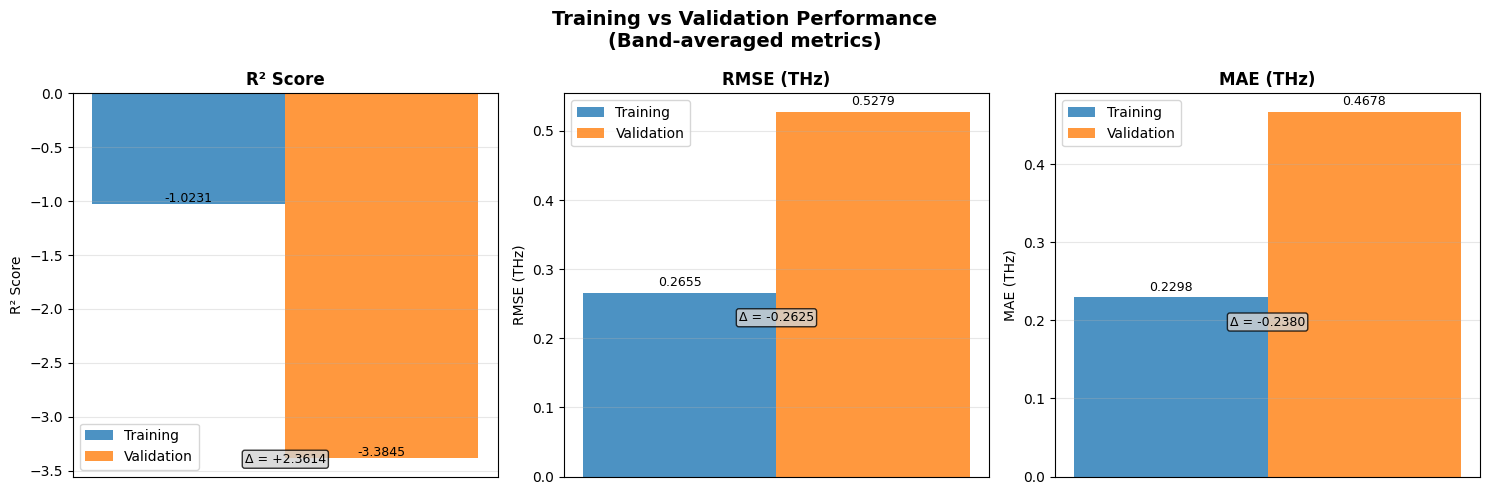

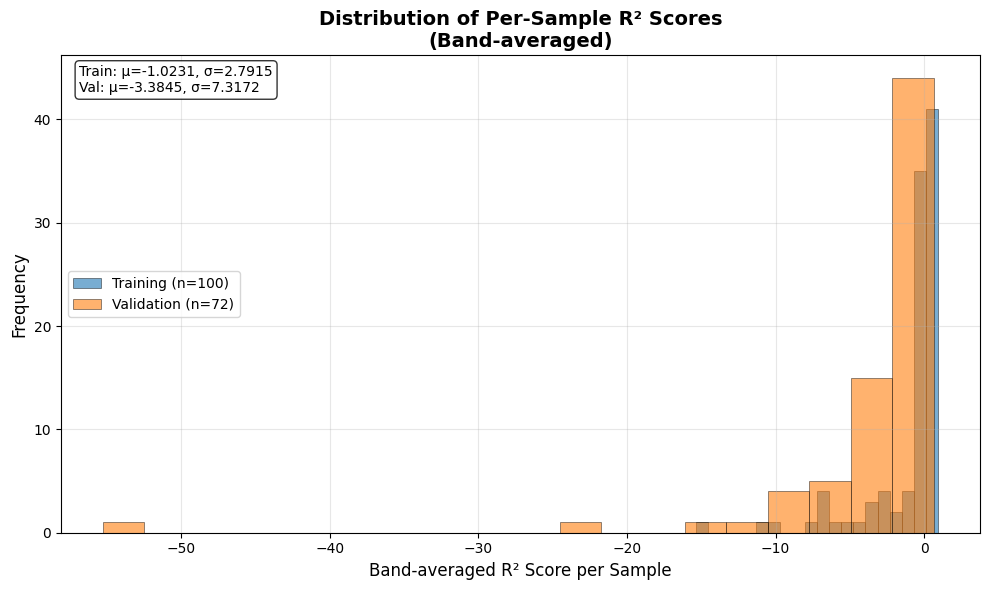

📊 VISUAL COMPARISON COMPLETE
Key observations from the charts:
⚠️  Training R² is notably higher than validation R²
⚠️  Training errors are lower (potential overfitting)


In [126]:
# 📊 Visual Comparison: Training vs Validation Metrics
import matplotlib.pyplot as plt
import numpy as np

# Check if both training and validation results are available
if 'train_avg_of_sample_avg_r2' in globals() and 'avg_of_sample_avg_r2' in globals():
    
    # Prepare data for plotting
    metrics_names = ['R² Score', 'RMSE (THz)', 'MAE (THz)']
    
    training_values = [
        train_avg_of_sample_avg_r2,
        train_avg_of_sample_avg_rmse, 
        train_avg_of_sample_avg_mae
    ]
    
    validation_values = [
        avg_of_sample_avg_r2,
        avg_of_sample_avg_rmse,
        avg_of_sample_avg_mae
    ]
    
    # Create comparison bar chart
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (metric, train_val, val_val) in enumerate(zip(metrics_names, training_values, validation_values)):
        x = np.arange(1)
        width = 0.35
        
        bars1 = axes[i].bar(x - width/2, train_val, width, label='Training', 
                           color='tab:blue', alpha=0.8)
        bars2 = axes[i].bar(x + width/2, val_val, width, label='Validation', 
                           color='tab:orange', alpha=0.8)
        
        axes[i].set_title(f'{metric}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(metric, fontsize=10)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add value labels on bars
        axes[i].text(x - width/2, train_val + (max(train_val, val_val) * 0.01), 
                    f'{train_val:.4f}', ha='center', va='bottom', fontsize=9)
        axes[i].text(x + width/2, val_val + (max(train_val, val_val) * 0.01), 
                    f'{val_val:.4f}', ha='center', va='bottom', fontsize=9)
        
        # Remove x-axis ticks since we only have one comparison
        axes[i].set_xticks([])
        
        # Calculate and show difference
        diff = train_val - val_val
        diff_text = f'Δ = {diff:+.4f}'
        axes[i].text(0, min(train_val, val_val) - (max(train_val, val_val) * 0.05), 
                    diff_text, ha='center', va='top', fontsize=9, 
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle('Training vs Validation Performance\n(Band-averaged metrics)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Additional histogram comparing sample-wise R² distributions
    if len(train_sample_avg_r2) > 0 and len(sample_avg_r2) > 0:
        fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
        
        # Plot histograms
        ax2.hist(train_sample_avg_r2, bins=20, alpha=0.6, label=f'Training (n={len(train_sample_avg_r2)})', 
                color='tab:blue', edgecolor='black', linewidth=0.5)
        ax2.hist(sample_avg_r2, bins=20, alpha=0.6, label=f'Validation (n={len(sample_avg_r2)})', 
                color='tab:orange', edgecolor='black', linewidth=0.5)
        
        ax2.set_xlabel('Band-averaged R² Score per Sample', fontsize=12)
        ax2.set_ylabel('Frequency', fontsize=12)
        ax2.set_title('Distribution of Per-Sample R² Scores\n(Band-averaged)', fontsize=14, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Add statistics
        train_stats = f'Train: μ={np.mean(train_sample_avg_r2):.4f}, σ={np.std(train_sample_avg_r2):.4f}'
        val_stats = f'Val: μ={np.mean(sample_avg_r2):.4f}, σ={np.std(sample_avg_r2):.4f}'
        
        ax2.text(0.02, 0.98, train_stats + '\n' + val_stats, 
                transform=ax2.transAxes, fontsize=10, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    # Summary interpretation
    print("📊 VISUAL COMPARISON COMPLETE")
    print("=" * 50)
    print("Key observations from the charts:")
    
    r2_diff = training_values[0] - validation_values[0]
    rmse_diff = training_values[1] - validation_values[1]
    mae_diff = training_values[2] - validation_values[2]
    
    if abs(r2_diff) < 0.01:
        print("✅ R² scores are very similar between training and validation")
    elif r2_diff > 0.01:
        print("⚠️  Training R² is notably higher than validation R²")
    else:
        print("⚠️  Validation R² is notably higher than training R² (unusual)")
    
    if abs(rmse_diff) < 0.05 and abs(mae_diff) < 0.05:
        print("✅ Error metrics (RMSE/MAE) are well balanced")
    elif rmse_diff < -0.05 and mae_diff < -0.05:
        print("⚠️  Training errors are lower (potential overfitting)")
    else:
        print("✅ Error metrics show reasonable training/validation gap")
    
    print("=" * 50)
    
else:
    print("⚠️  Cannot create comparison plots:")
    if 'train_avg_of_sample_avg_r2' not in globals():
        print("   - Training evaluation results not available")
    if 'avg_of_sample_avg_r2' not in globals():
        print("   - Validation evaluation results not available")
    print("   Please run both training and validation evaluation cells first")